<a href="https://www.kaggle.com/code/lalit7881/predicting-irrigation-need-eda?scriptVersionId=311290142" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

## Import packages

# General purpose modules
import time
from copy import deepcopy
import warnings
import math
from itertools import combinations

# Data handling and visualization modules
import numpy as np
import pandas as pd
pd.set_option('future.no_silent_downcasting', True)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings("ignore")
#import cupy as cp

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/playground-series-s6e4/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e4/train.csv
/kaggle/input/competitions/playground-series-s6e4/test.csv


## Loading dataaset

In [2]:
df_train=pd.read_csv('/kaggle/input/competitions/playground-series-s6e4/train.csv')
df_test=pd.read_csv('/kaggle/input/competitions/playground-series-s6e4/test.csv')

In [3]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 21 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Soil_Type                630000 non-null  object 
 2   Soil_pH                  630000 non-null  float64
 3   Soil_Moisture            630000 non-null  float64
 4   Organic_Carbon           630000 non-null  float64
 5   Electrical_Conductivity  630000 non-null  float64
 6   Temperature_C            630000 non-null  float64
 7   Humidity                 630000 non-null  float64
 8   Rainfall_mm              630000 non-null  float64
 9   Sunlight_Hours           630000 non-null  float64
 10  Wind_Speed_kmh           630000 non-null  float64
 11  Crop_Type                630000 non-null  object 
 12  Crop_Growth_Stage        630000 non-null  object 
 13  Season                   630000 non-null  object 
 14  Irri

In [4]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270000 entries, 0 to 269999
Data columns (total 20 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       270000 non-null  int64  
 1   Soil_Type                270000 non-null  object 
 2   Soil_pH                  270000 non-null  float64
 3   Soil_Moisture            270000 non-null  float64
 4   Organic_Carbon           270000 non-null  float64
 5   Electrical_Conductivity  270000 non-null  float64
 6   Temperature_C            270000 non-null  float64
 7   Humidity                 270000 non-null  float64
 8   Rainfall_mm              270000 non-null  float64
 9   Sunlight_Hours           270000 non-null  float64
 10  Wind_Speed_kmh           270000 non-null  float64
 11  Crop_Type                270000 non-null  object 
 12  Crop_Growth_Stage        270000 non-null  object 
 13  Season                   270000 non-null  object 
 14  Irri

In [5]:
df_train.isnull().sum(),df_test.isnull().sum()

(id                         0
 Soil_Type                  0
 Soil_pH                    0
 Soil_Moisture              0
 Organic_Carbon             0
 Electrical_Conductivity    0
 Temperature_C              0
 Humidity                   0
 Rainfall_mm                0
 Sunlight_Hours             0
 Wind_Speed_kmh             0
 Crop_Type                  0
 Crop_Growth_Stage          0
 Season                     0
 Irrigation_Type            0
 Water_Source               0
 Field_Area_hectare         0
 Mulching_Used              0
 Previous_Irrigation_mm     0
 Region                     0
 Irrigation_Need            0
 dtype: int64,
 id                         0
 Soil_Type                  0
 Soil_pH                    0
 Soil_Moisture              0
 Organic_Carbon             0
 Electrical_Conductivity    0
 Temperature_C              0
 Humidity                   0
 Rainfall_mm                0
 Sunlight_Hours             0
 Wind_Speed_kmh             0
 Crop_Type               

In [6]:
df_train.head(5)

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,...,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,...,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,...,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,...,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,...,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,...,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


In [7]:
df_train= df_train.drop(['id'],axis =1)
df_test= df_test.drop(['id'],axis =1)

## EDA

In [8]:
numerical_columns = df_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_columns = df_train.select_dtypes(include=['object', 'category']).columns.tolist()
print("\nCategorical Columns:")
print(categorical_columns)
print(f"\nTotal number of categorical columns: {len(categorical_columns)}")

print("\nNumerical Columns:")
print(numerical_columns)
print(f"\nTotal number of numerical columns: {len(numerical_columns)}")


Categorical Columns:
['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region', 'Irrigation_Need']

Total number of categorical columns: 9

Numerical Columns:
['Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Field_Area_hectare', 'Previous_Irrigation_mm']

Total number of numerical columns: 11


## Numarical columns

In [9]:
df_train[numerical_columns].describe()

,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,Previous_Irrigation_mm
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,6.482497,37.304482,0.922858,1.744605,26.998166,61.563180,1462.207566,7.513382,10.375394,7.517745,62.318177
std,0.922504,16.377082,0.365808,0.952321,8.623621,19.708152,612.989738,1.999322,5.689458,4.218124,34.246939
min,4.800000,8.000000,0.300000,0.100000,12.000000,25.000000,0.380000,4.000000,0.500000,0.300000,0.020000
25%,5.690000,23.340000,0.610000,0.930000,19.517500,45.390000,954.570000,5.760000,5.280000,3.880000,33.140000
50%,6.440000,37.750000,0.910000,1.740000,26.960000,61.650000,1467.160000,7.580000,10.480000,7.380000,61.150000
75%,7.270000,51.270000,1.220000,2.580000,34.540000,79.120000,2054.280000,9.250000,15.430000,11.140000,92.690000
max,8.200000,64.990000,1.600000,3.500000,42.000000,94.990000,2499.690000,11.000000,20.000000,15.000000,119.990000


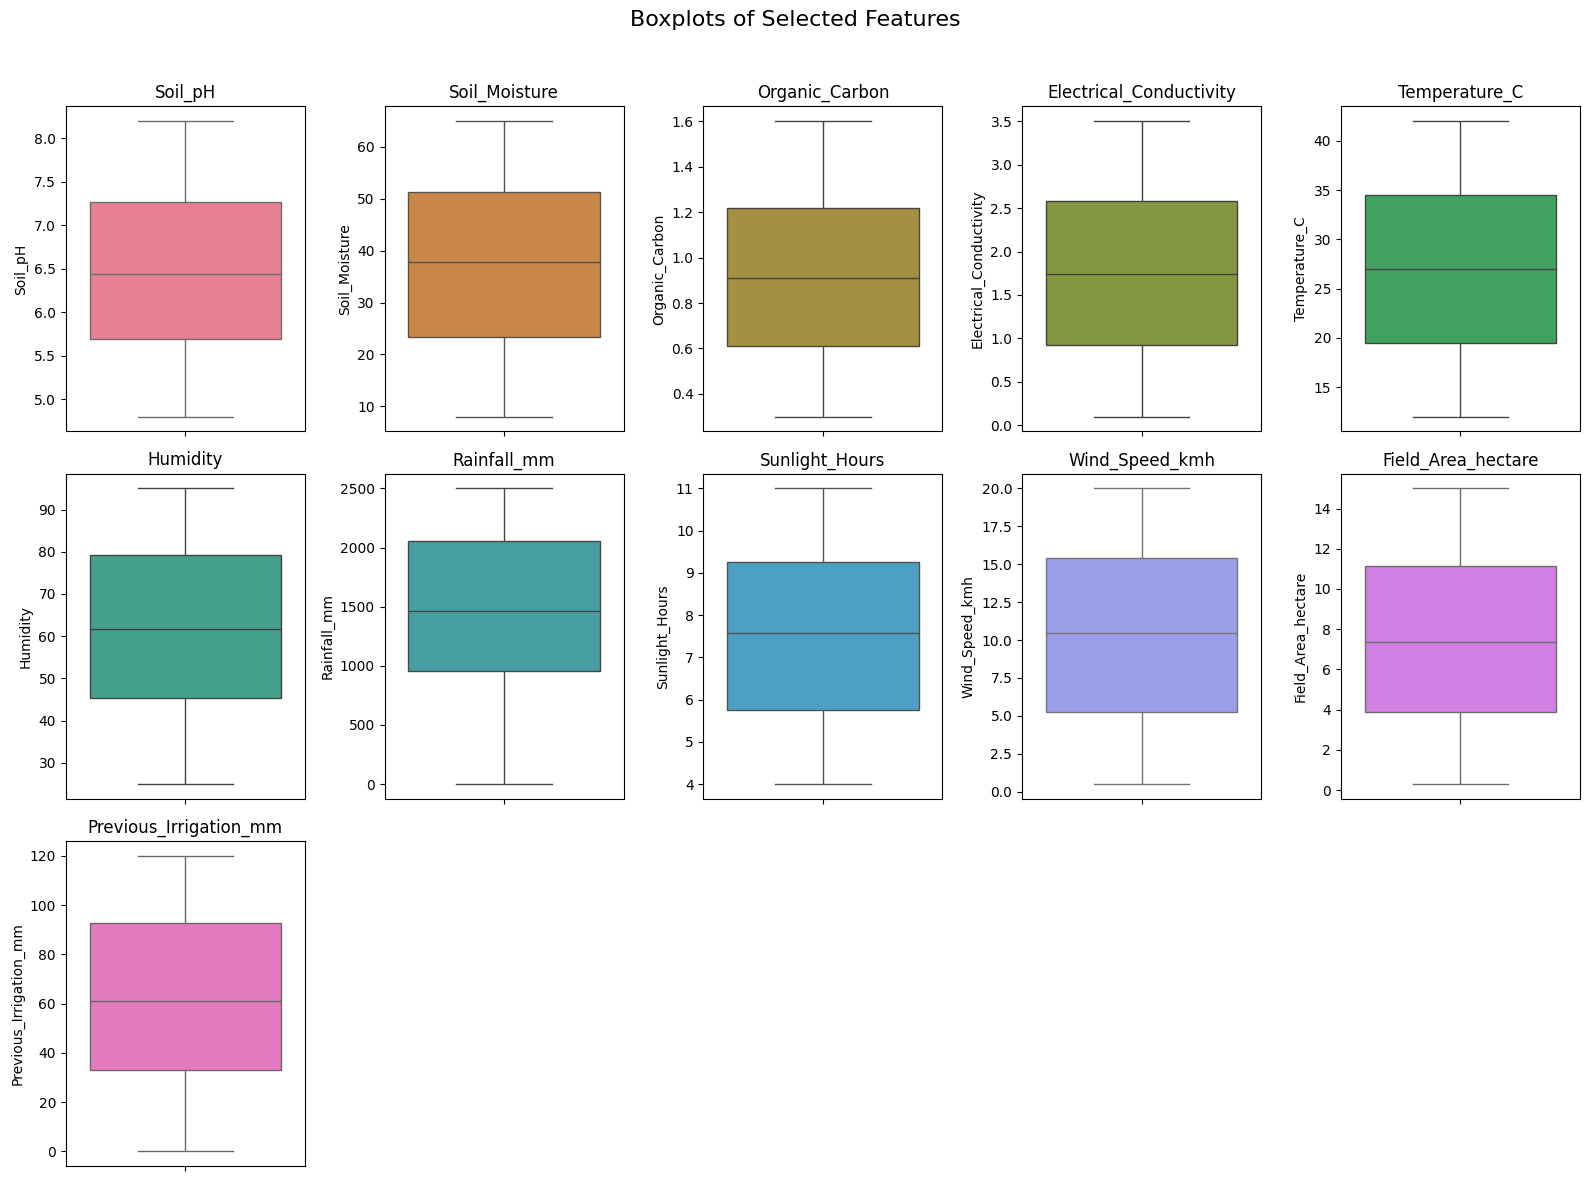

In [10]:
fig, axes = plt.subplots(nrows=3, ncols=5, figsize=(16, 12))
fig.suptitle('Boxplots of Selected Features', fontsize=16)

axes = axes.flatten()

# Generate a color palette
colors = sns.color_palette("husl", len(numerical_columns))

for i, col in enumerate(df_train[numerical_columns]):
    sns.boxplot(y=df_train[col], ax=axes[i], color=colors[i])
    axes[i].set_title(col)

# Remove extra empty plots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

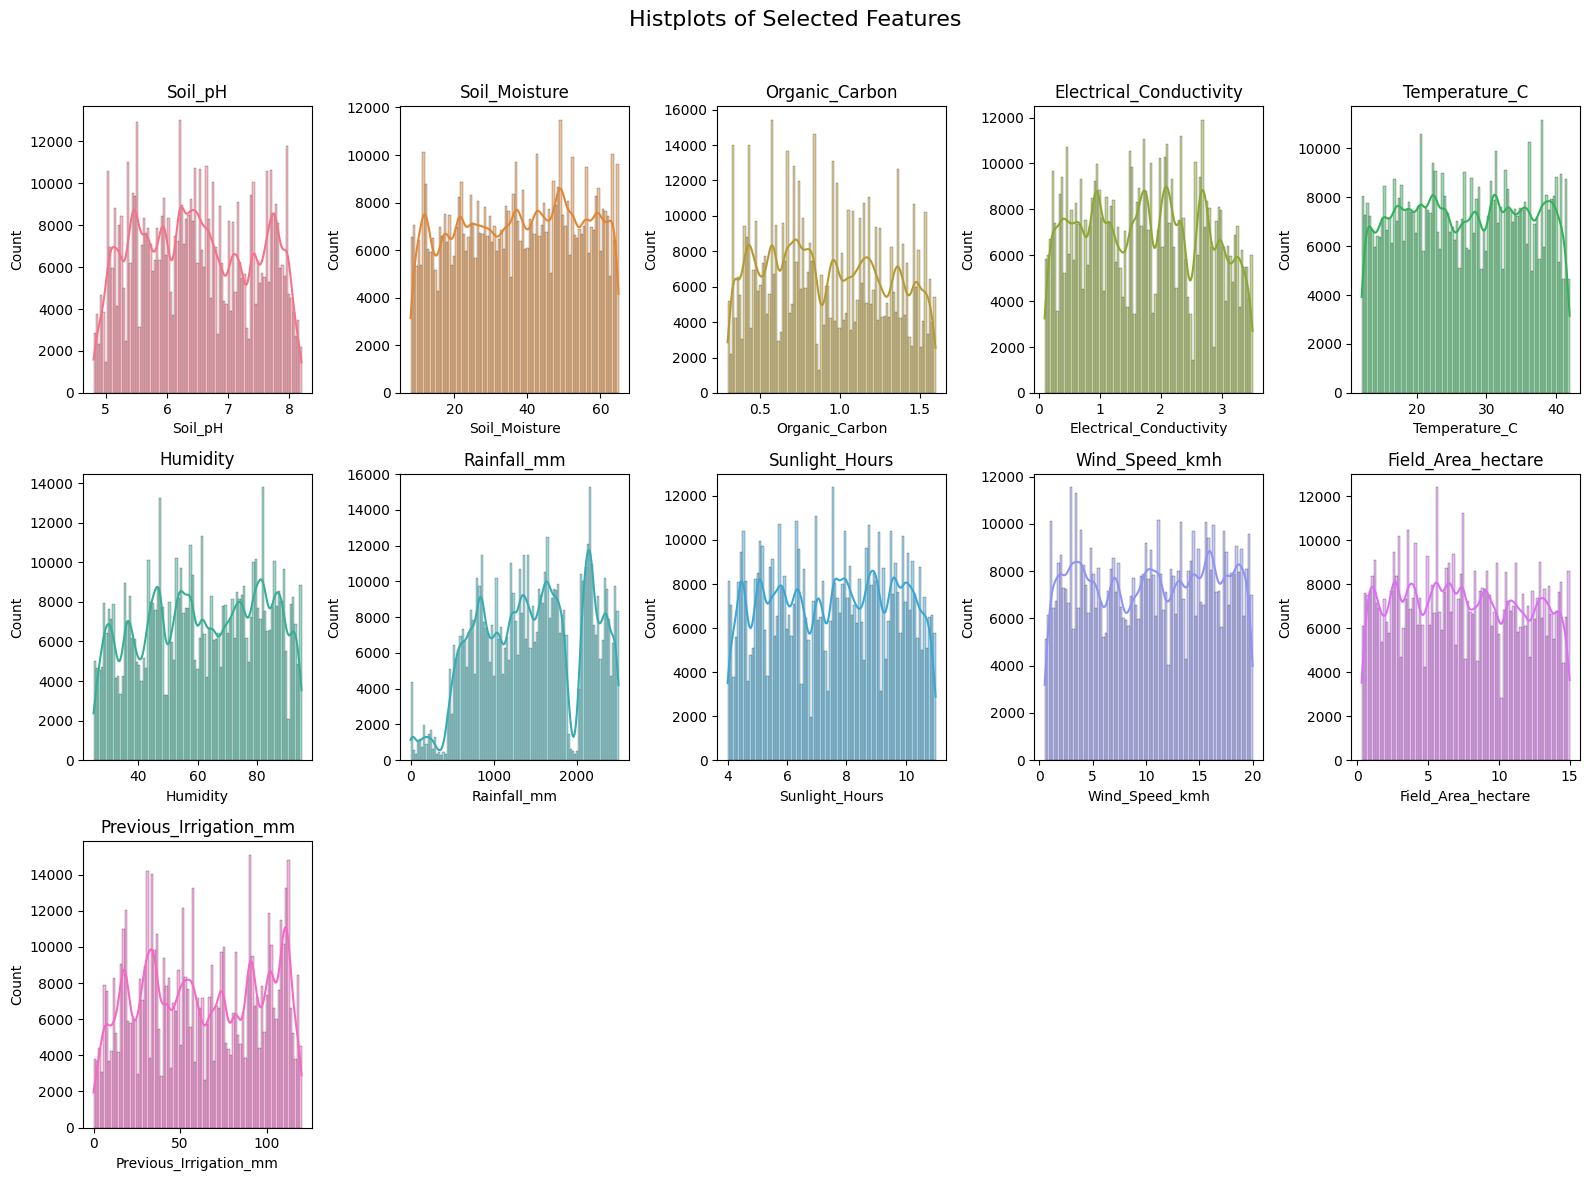

In [11]:
fig, axes = plt.subplots(nrows=3, ncols=5, figsize=(16, 12))
fig.suptitle('Histplots of Selected Features', fontsize=16)

axes = axes.flatten()

# Create color palette
colors = sns.color_palette("husl", len(numerical_columns))

for i, col in enumerate(df_train[numerical_columns]):
    sns.histplot(
        x=df_train[col],
        kde=True,
        ax=axes[i],
        color=colors[i],
        edgecolor='black'   # makes bars clearer
    )
    axes[i].set_title(col)

# Remove extra plots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## Heatmap

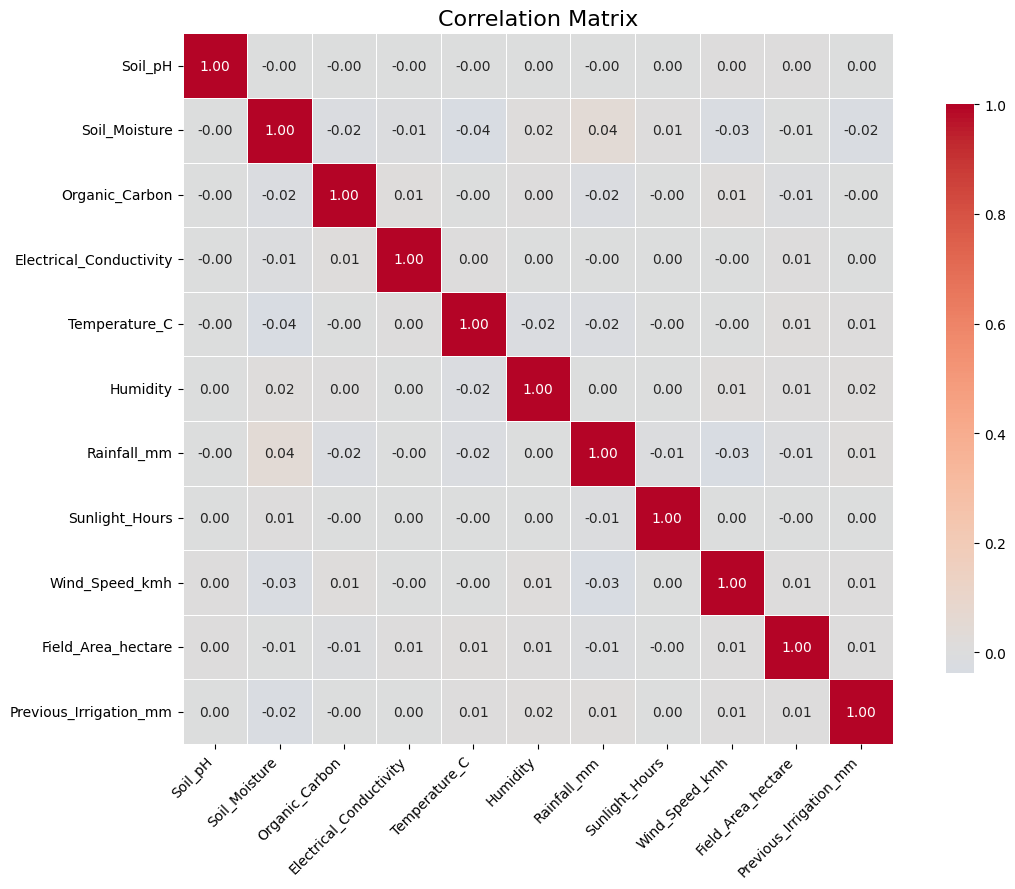

In [12]:
plt.figure(figsize=(12, 9))

sns.heatmap(
    df_train[numerical_columns].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5,
    center=0,                 # centers color at 0 (important!)
    square=True,              # makes cells square
    cbar_kws={"shrink": 0.8}  # better colorbar size
)

plt.title("Correlation Matrix", fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [13]:
print(df_train.columns)

Index(['Soil_Type', 'Soil_pH', 'Soil_Moisture', 'Organic_Carbon',
       'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm',
       'Sunlight_Hours', 'Wind_Speed_kmh', 'Crop_Type', 'Crop_Growth_Stage',
       'Season', 'Irrigation_Type', 'Water_Source', 'Field_Area_hectare',
       'Mulching_Used', 'Previous_Irrigation_mm', 'Region', 'Irrigation_Need'],
      dtype='object')


## Pairplot

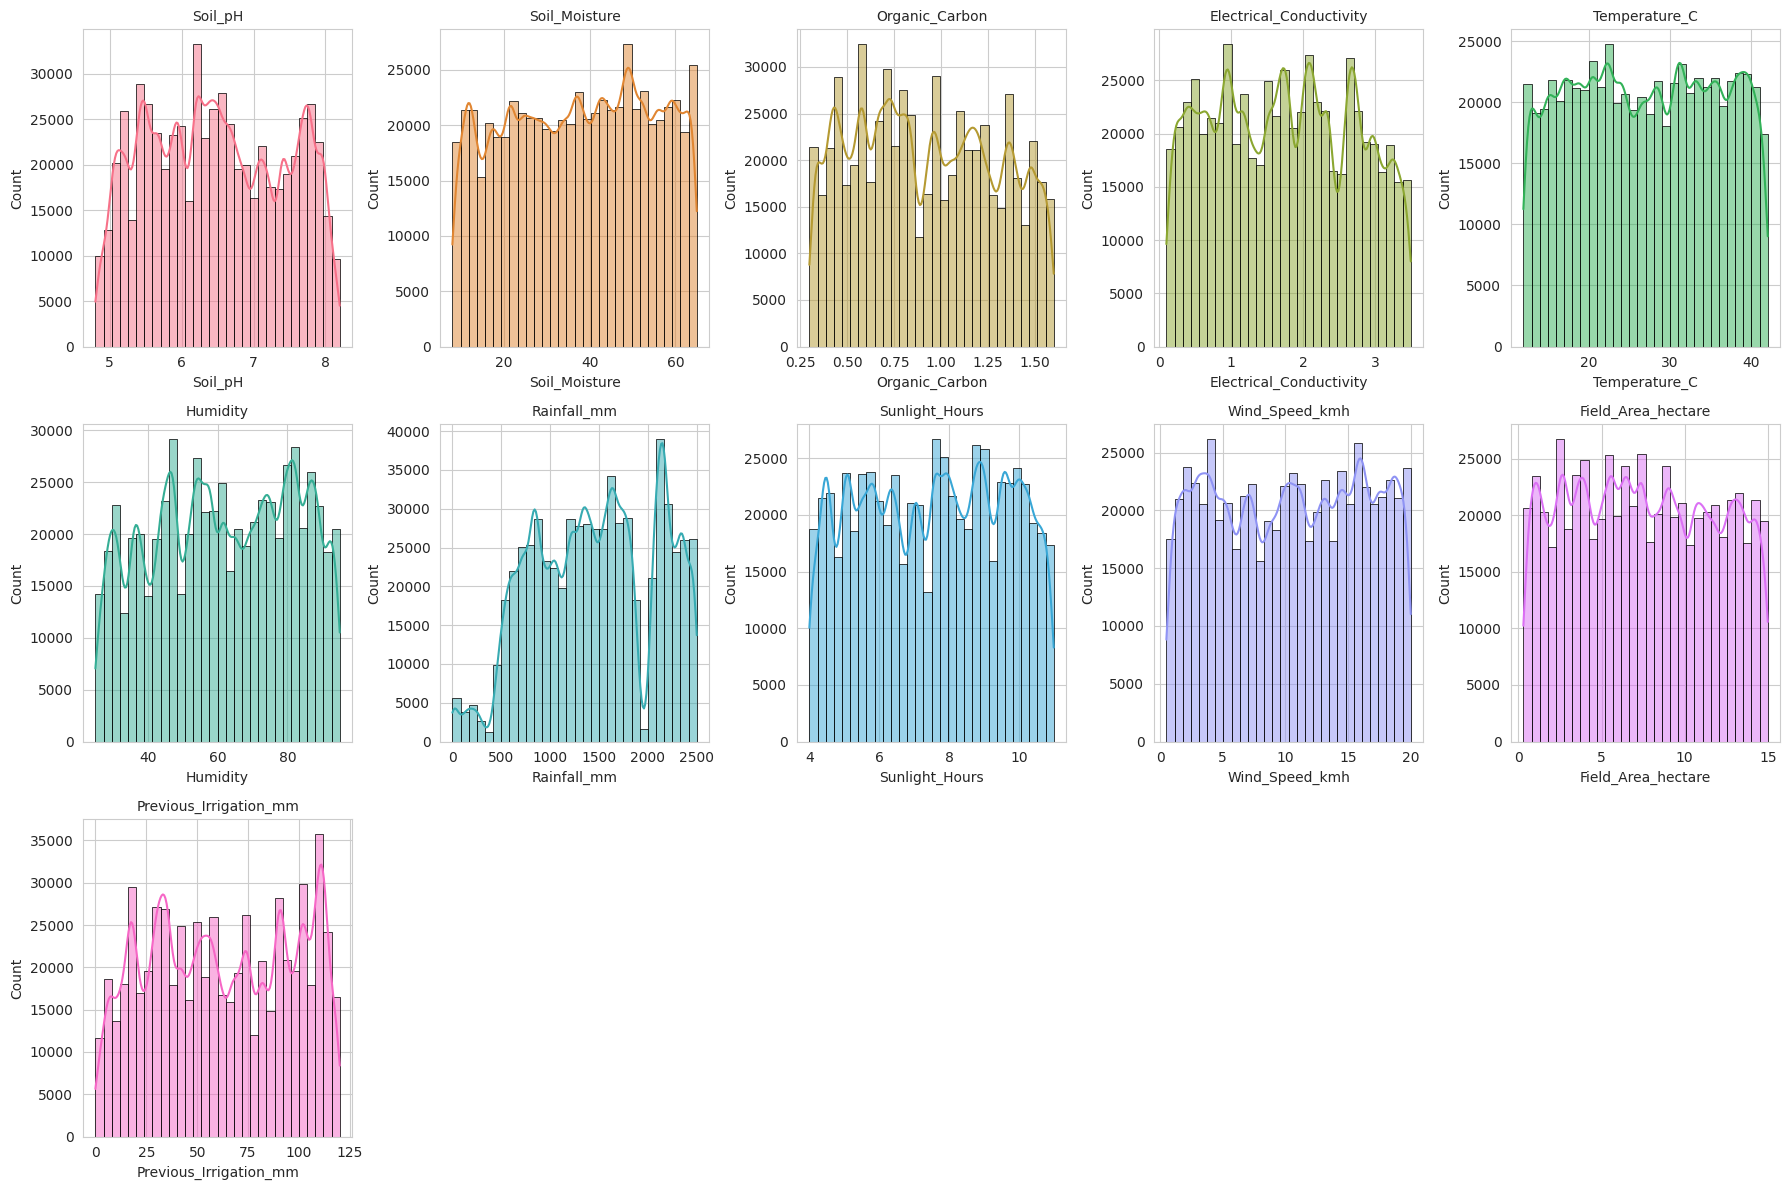

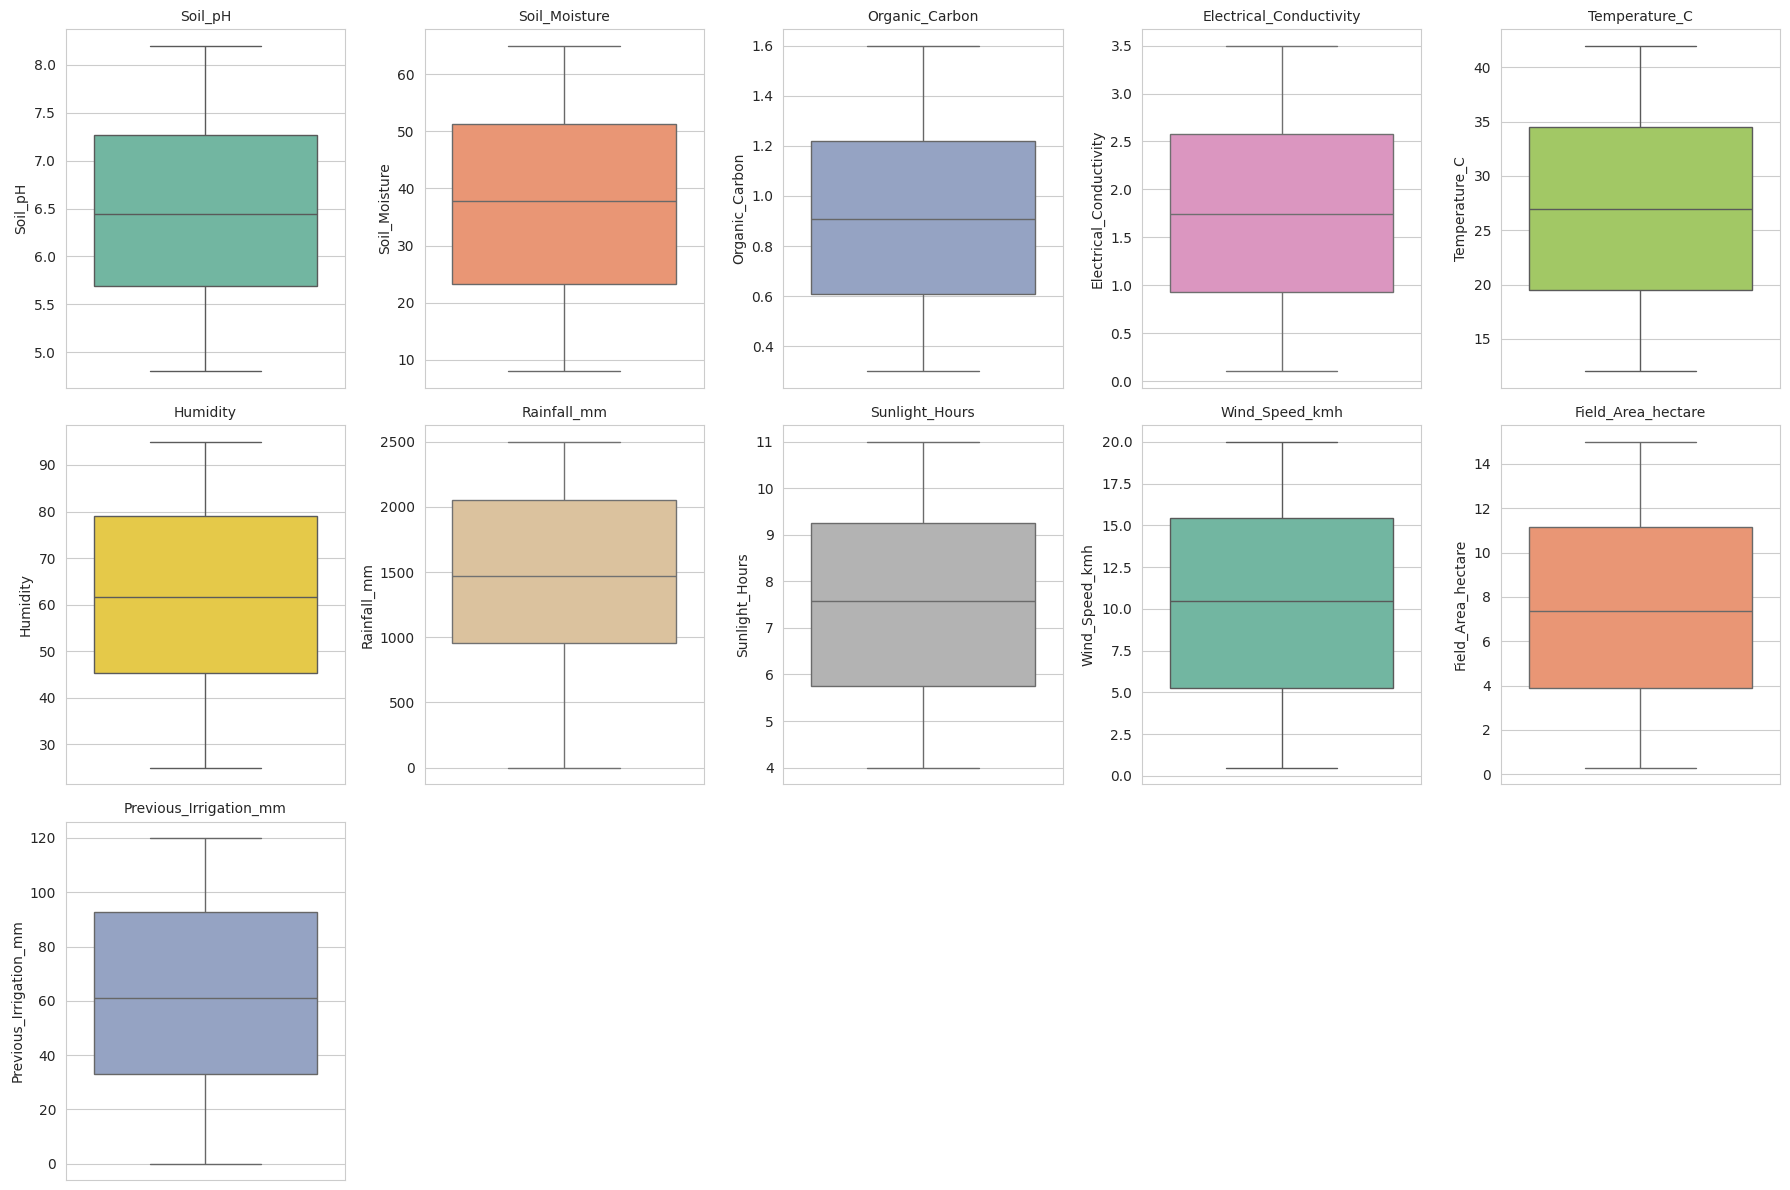

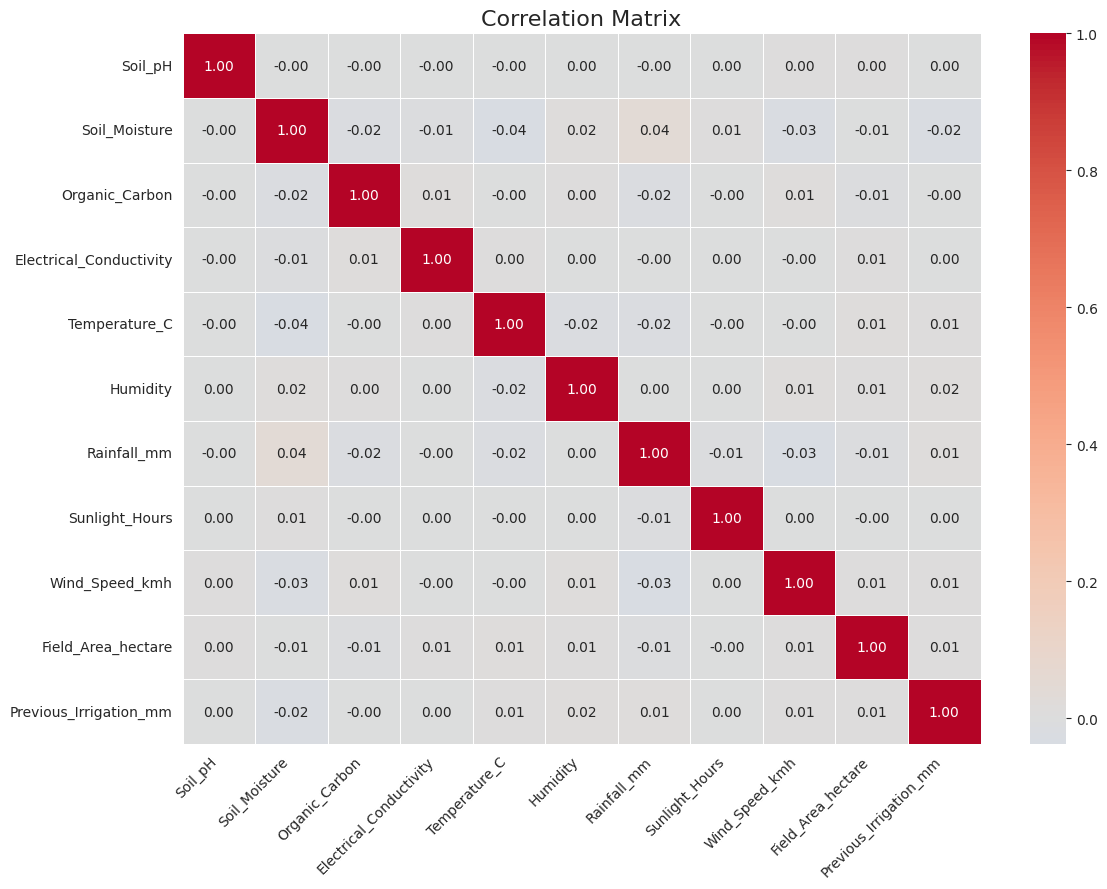

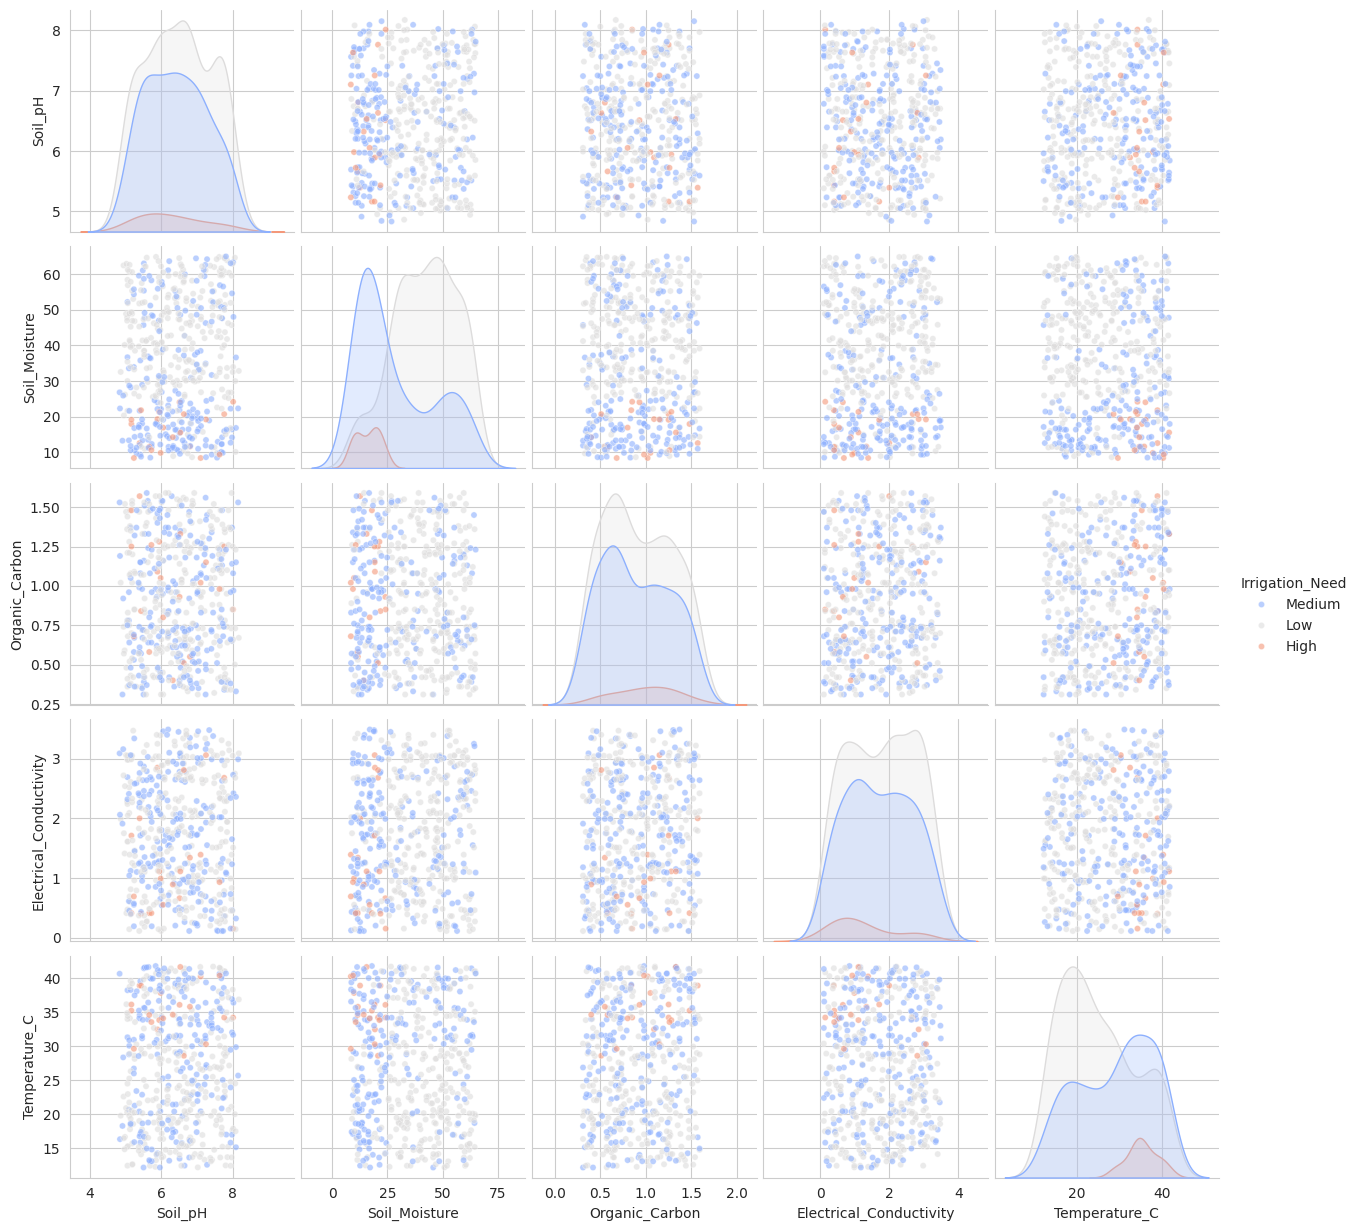

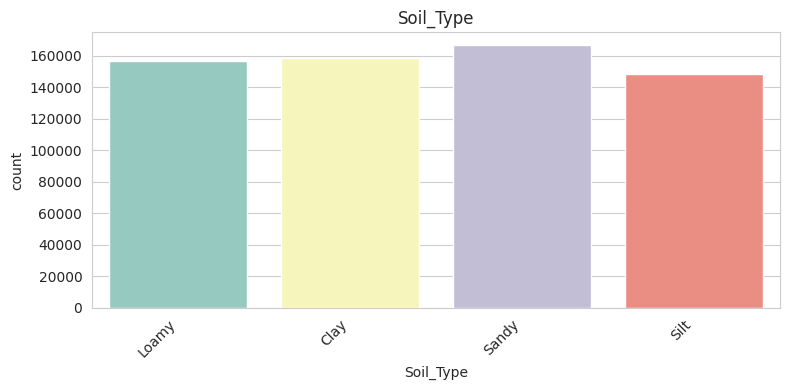

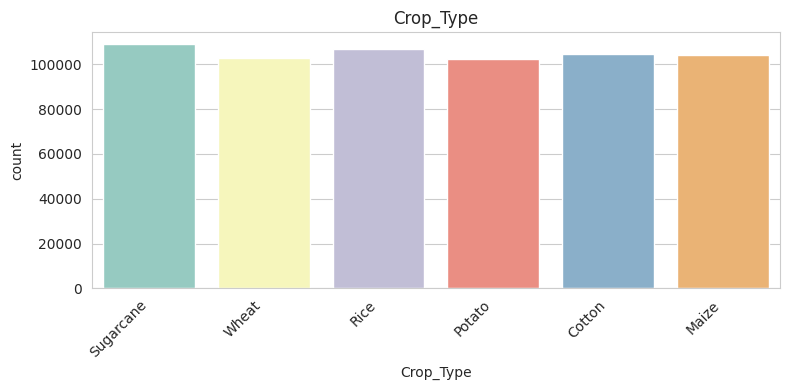

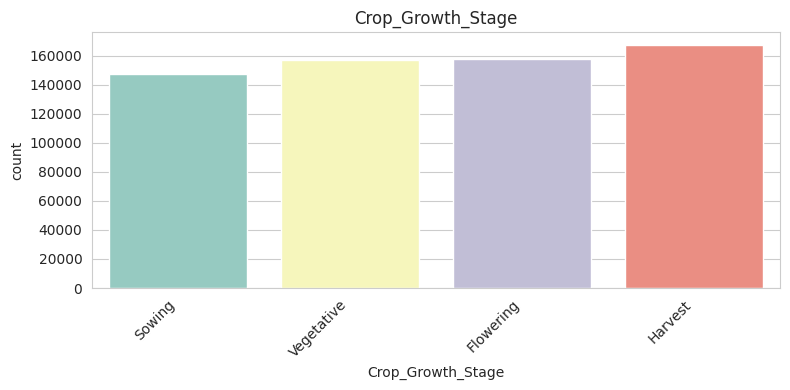

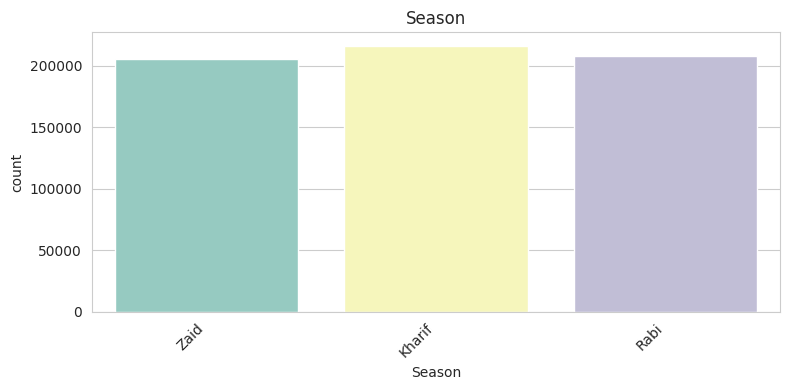

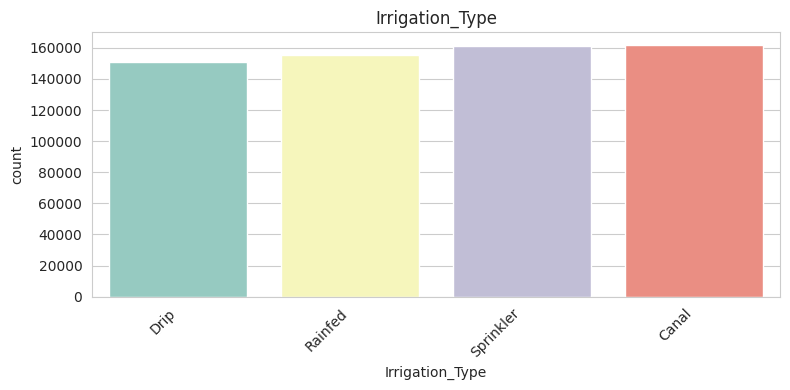

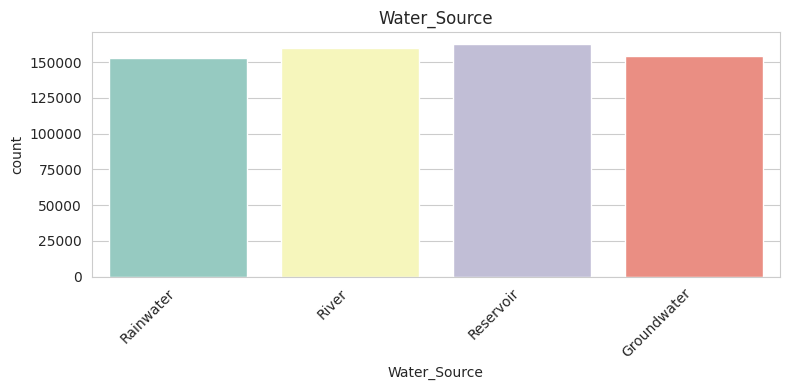

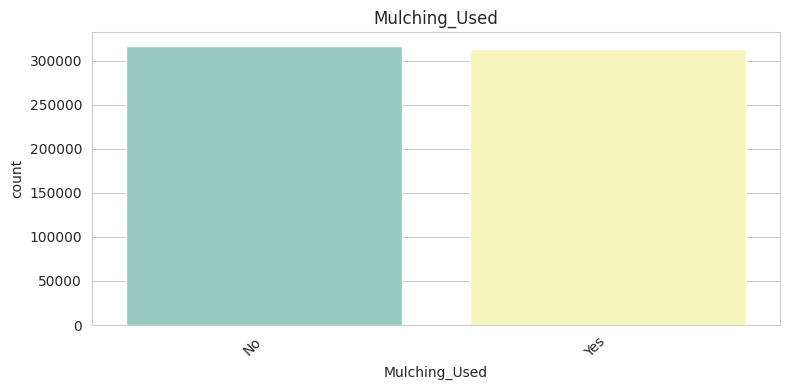

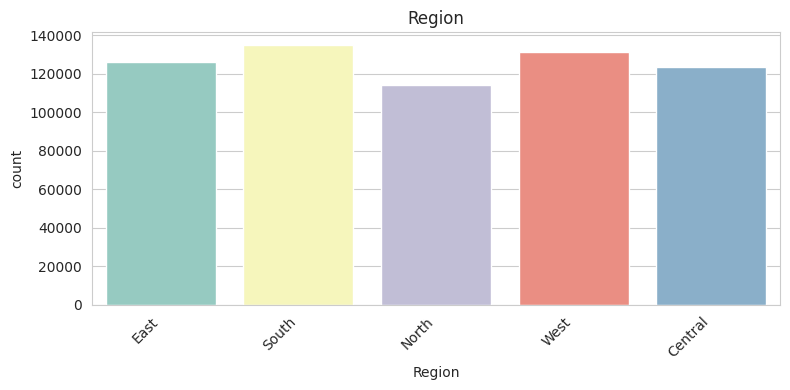

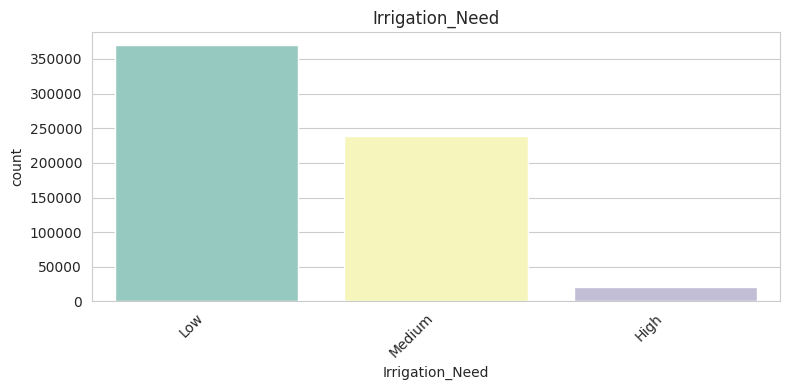

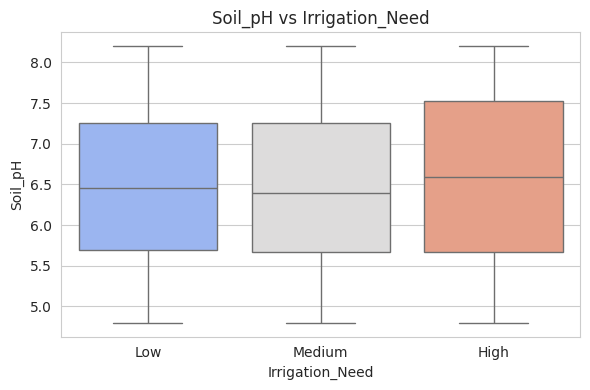

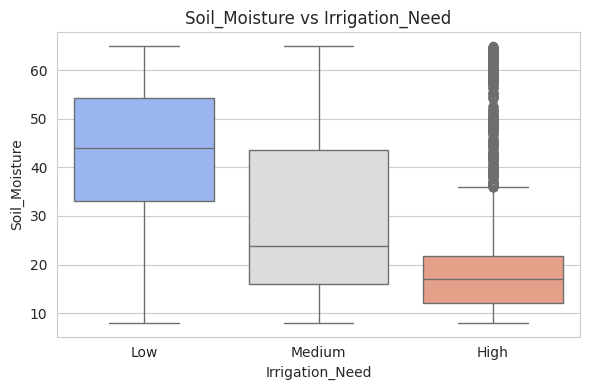

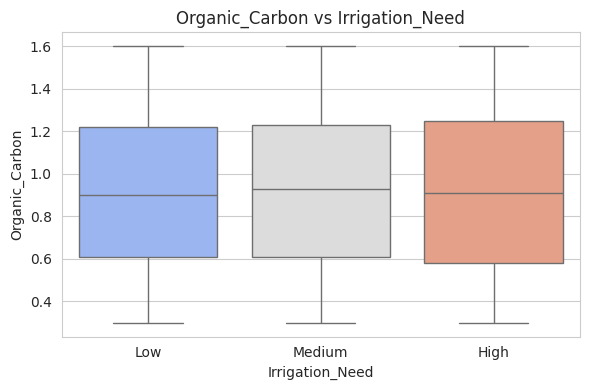

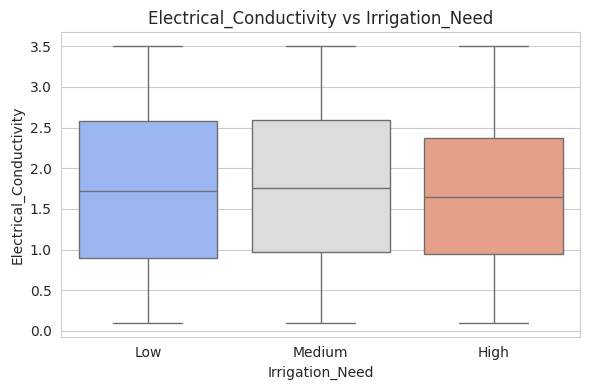

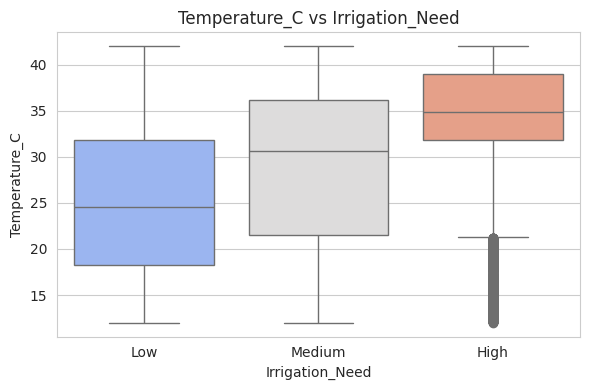

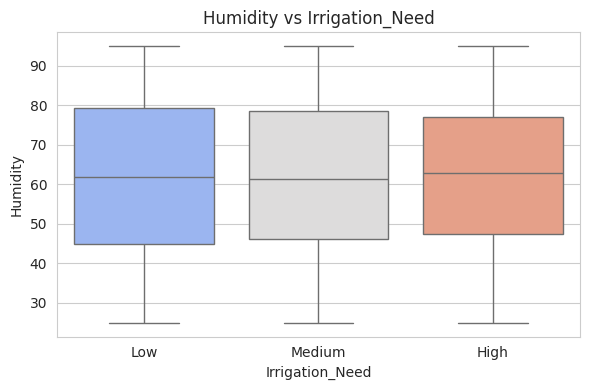

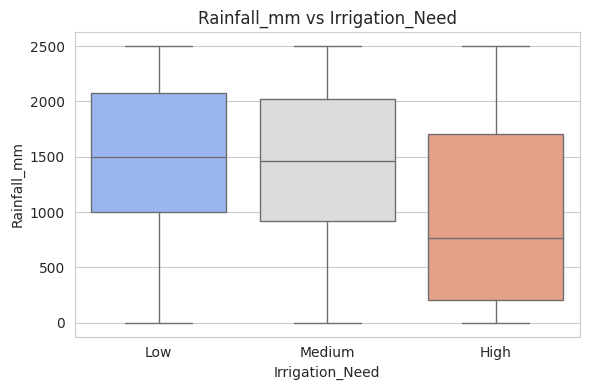

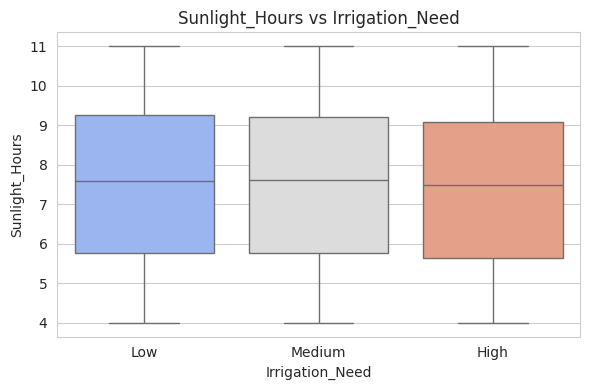

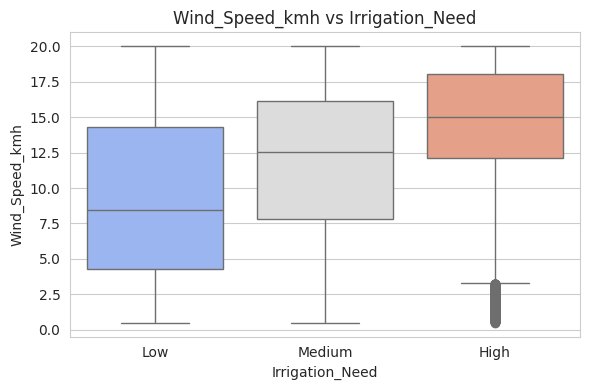

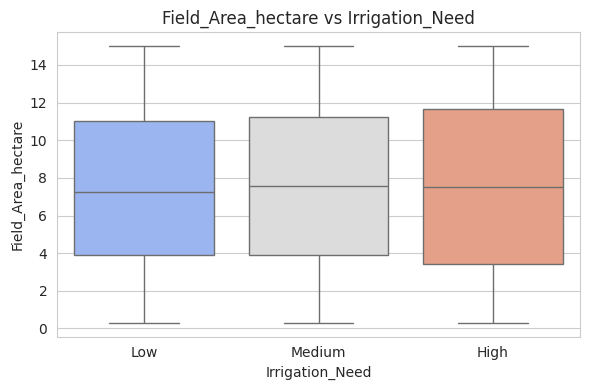

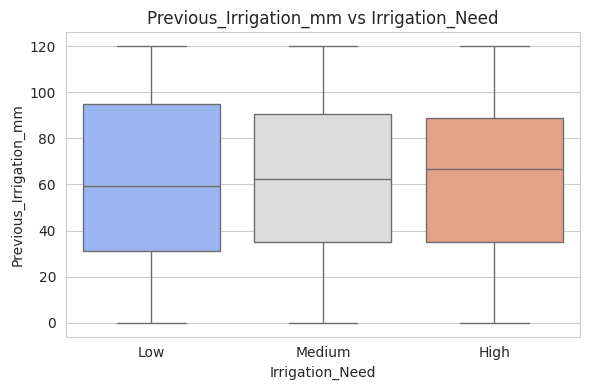

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Style
sns.set_style("whitegrid")

# ===============================
# Separate column types
# ===============================
numerical_columns = df_train.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df_train.select_dtypes(exclude=np.number).columns.tolist()

# ===============================
# 1. Histograms with KDE
# ===============================
n_cols = 5
n_rows = int(np.ceil(len(numerical_columns) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

colors = sns.color_palette("husl", len(numerical_columns))

for i, col in enumerate(numerical_columns):
    sns.histplot(
        data=df_train,
        x=col,
        kde=True,
        ax=axes[i],
        color=colors[i],
        edgecolor='black',
        bins=30
    )
    axes[i].set_title(f"{col}", fontsize=10)

# Remove empty plots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# ===============================
# 2. Boxplots
# ===============================
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

colors = sns.color_palette("Set2", len(numerical_columns))

for i, col in enumerate(numerical_columns):
    sns.boxplot(
        data=df_train,
        y=col,
        ax=axes[i],
        color=colors[i]
    )
    axes[i].set_title(f"{col}", fontsize=10)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# ===============================
# 3. Correlation Heatmap
# ===============================
plt.figure(figsize=(12, 9))

corr = df_train[numerical_columns].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5,
    center=0
)

plt.title("Correlation Matrix", fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# ===============================
# 4. Pairplot
# ===============================
# Handle target safely
if 'Irrigation_Need' in df_train.columns:
    
    if df_train['Irrigation_Need'].nunique() > 10:
        df_train['Irrigation_Level'] = pd.qcut(
            df_train['Irrigation_Need'],
            q=3,
            labels=['Low', 'Medium', 'High']
        )
        hue_col = 'Irrigation_Level'
    else:
        hue_col = 'Irrigation_Need'

    sns.pairplot(
        df_train.sample(min(500, len(df_train))),
        vars=numerical_columns[:5],
        hue=hue_col,
        palette='coolwarm',
        diag_kind='kde',
        plot_kws={'alpha': 0.6, 's': 20}
    )

    plt.show()

# ===============================
# 5. Countplots (Categorical)
# ===============================
for col in categorical_columns:
    plt.figure(figsize=(8, 4))
    
    sns.countplot(
        data=df_train,
        x=col,
        palette='Set3'
    )
    
    plt.title(f"{col}", fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# ===============================
# 6. Target vs Numerical
# ===============================
if 'Irrigation_Need' in df_train.columns:
    
    for col in numerical_columns:
        plt.figure(figsize=(6, 4))
        
        sns.boxplot(
            data=df_train,   # ✅ FIXED
            x=hue_col,
            y=col,
            palette='coolwarm'
        )
        
        plt.title(f"{col} vs {hue_col}")
        plt.tight_layout()
        plt.show()

### Categorical Column Analysis

In [15]:
print(df_train[categorical_columns].dtypes)

Soil_Type            object
Crop_Type            object
Crop_Growth_Stage    object
Season               object
Irrigation_Type      object
Water_Source         object
Mulching_Used        object
Region               object
Irrigation_Need      object
dtype: object


In [16]:
print(df_train[categorical_columns].shape)

(630000, 9)


In [17]:
for col in categorical_columns:
    print(f"{col}: {df_train[col].nunique()} unique values")
    print(df_train[col].unique())

Soil_Type: 4 unique values
['Loamy' 'Clay' 'Sandy' 'Silt']
Crop_Type: 6 unique values
['Sugarcane' 'Wheat' 'Rice' 'Potato' 'Cotton' 'Maize']
Crop_Growth_Stage: 4 unique values
['Sowing' 'Vegetative' 'Flowering' 'Harvest']
Season: 3 unique values
['Zaid' 'Kharif' 'Rabi']
Irrigation_Type: 4 unique values
['Drip' 'Rainfed' 'Sprinkler' 'Canal']
Water_Source: 4 unique values
['Rainwater' 'River' 'Reservoir' 'Groundwater']
Mulching_Used: 2 unique values
['No' 'Yes']
Region: 5 unique values
['East' 'South' 'North' 'West' 'Central']
Irrigation_Need: 3 unique values
['Low' 'Medium' 'High']


In [18]:
for col in categorical_columns:
    print(f"\n{col} Value Counts:")
    print(df_train[col].value_counts())
    print(df_train[col].value_counts(normalize=True) * 100)  # percentage


Soil_Type Value Counts:
Soil_Type
Sandy    166509
Clay     158470
Loamy    156455
Silt     148566
Name: count, dtype: int64
Soil_Type
Sandy    26.430000
Clay     25.153968
Loamy    24.834127
Silt     23.581905
Name: proportion, dtype: float64

Crop_Type Value Counts:
Crop_Type
Sugarcane    108910
Rice         106697
Cotton       104645
Maize        104274
Wheat        103005
Potato       102469
Name: count, dtype: int64
Crop_Type
Sugarcane    17.287302
Rice         16.936032
Cotton       16.610317
Maize        16.551429
Wheat        16.350000
Potato       16.264921
Name: proportion, dtype: float64

Crop_Growth_Stage Value Counts:
Crop_Growth_Stage
Harvest       167689
Flowering     157563
Vegetative    157246
Sowing        147502
Name: count, dtype: int64
Crop_Growth_Stage
Harvest       26.617302
Flowering     25.010000
Vegetative    24.959683
Sowing        23.413016
Name: proportion, dtype: float64

Season Value Counts:
Season
Kharif    216561
Rabi      208033
Zaid      205406
Name: 

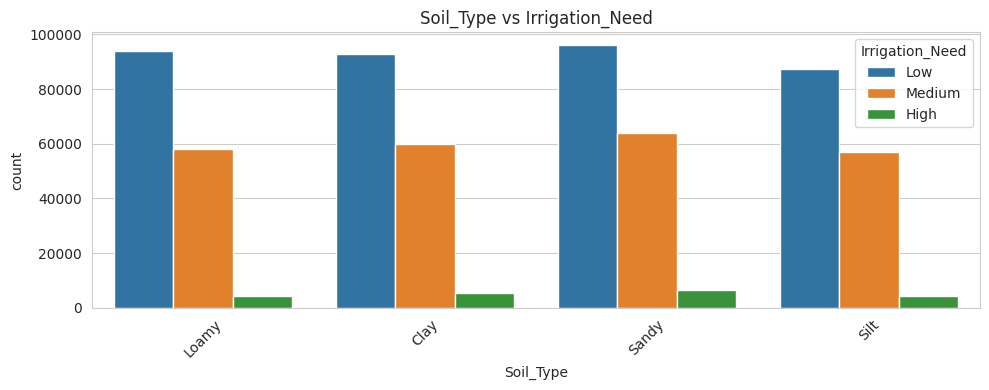

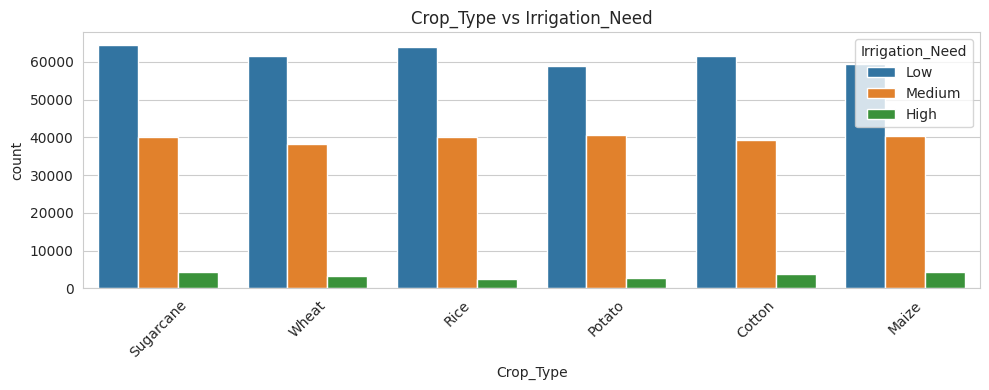

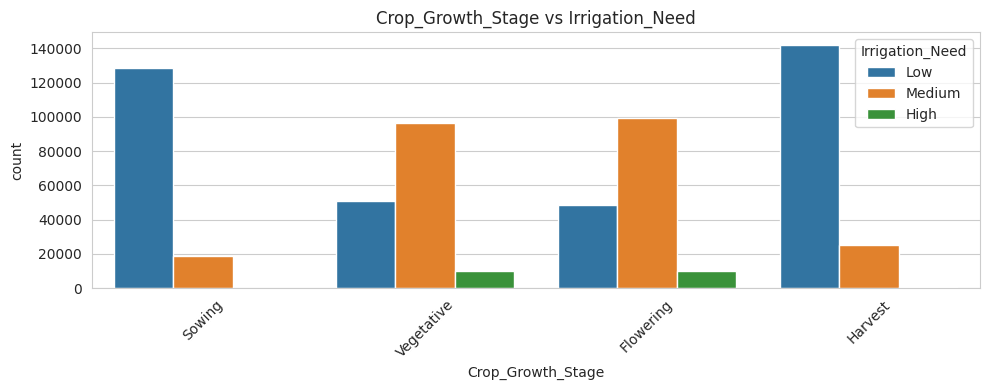

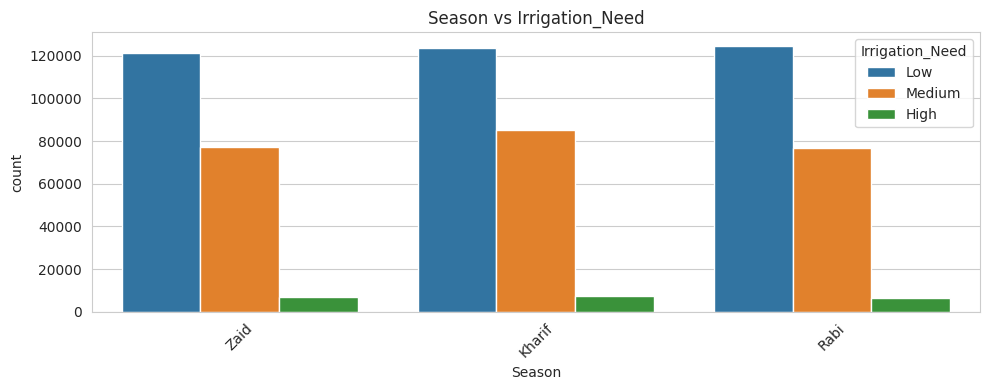

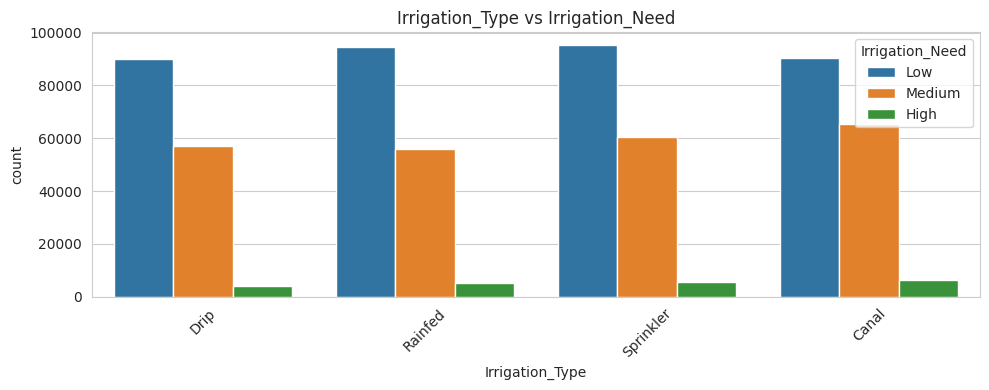

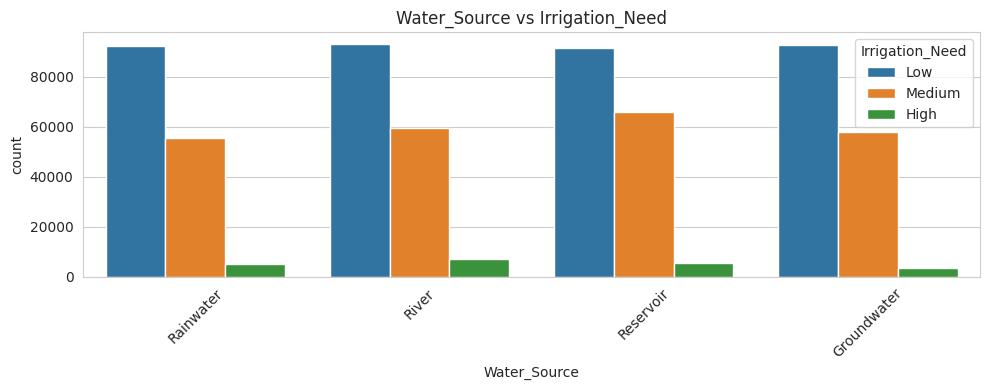

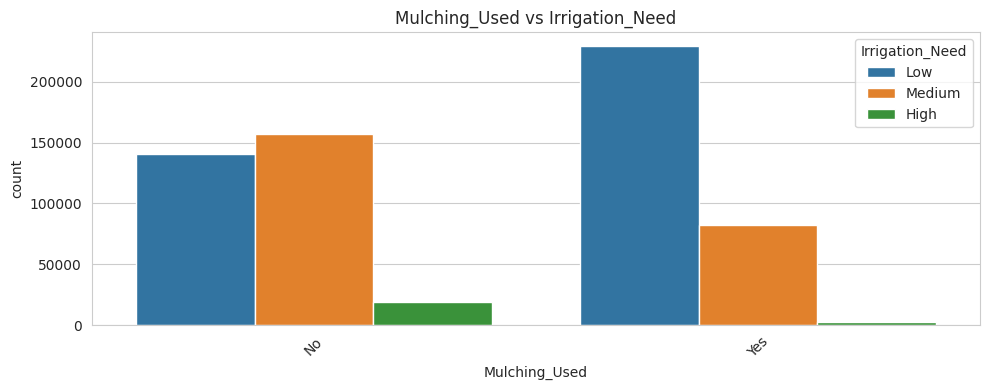

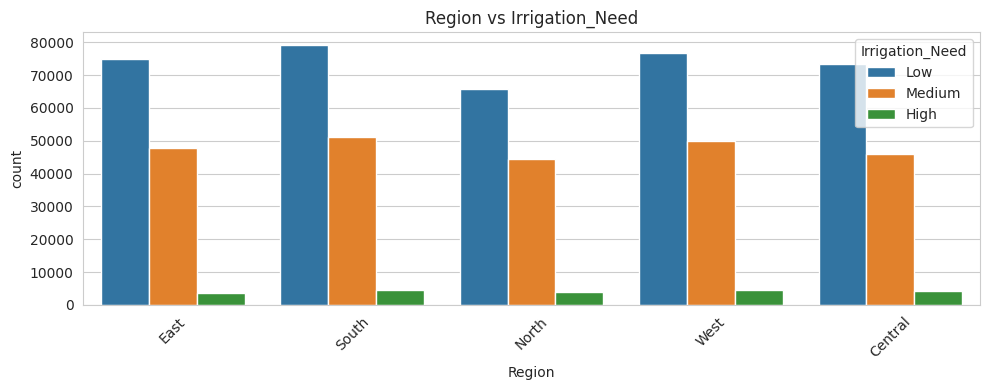

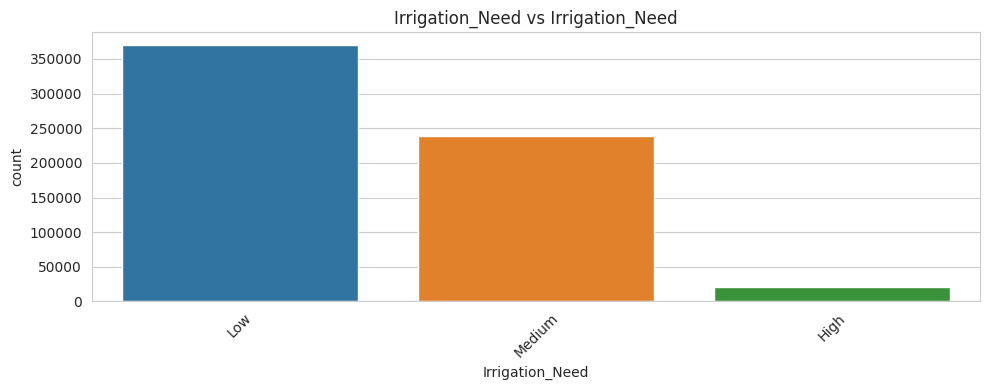

In [19]:
target = 'Irrigation_Need'  # replace with your target column
for col in categorical_columns:
    plt.figure(figsize=(10, 4))
    sns.countplot(data=df_train, x=col, hue=target)
    plt.title(f'{col} vs {target}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

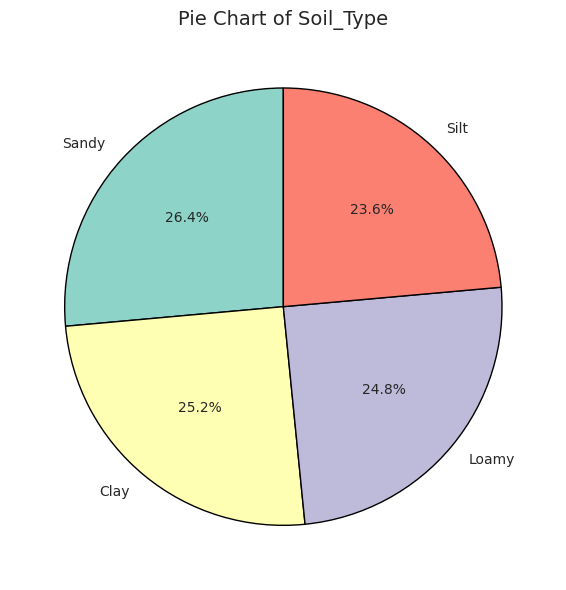

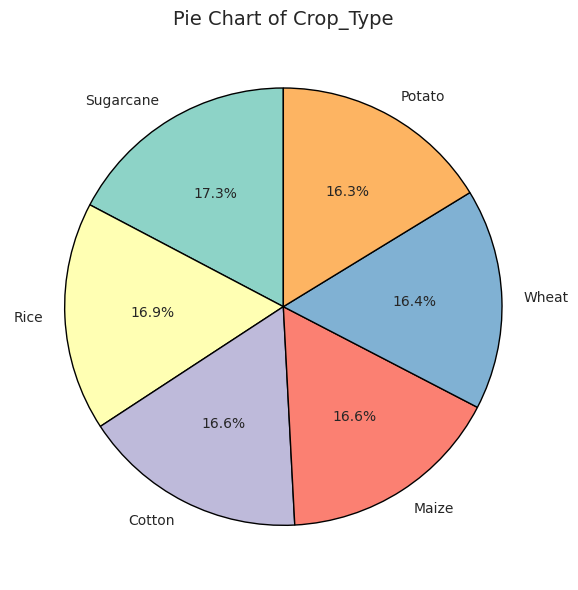

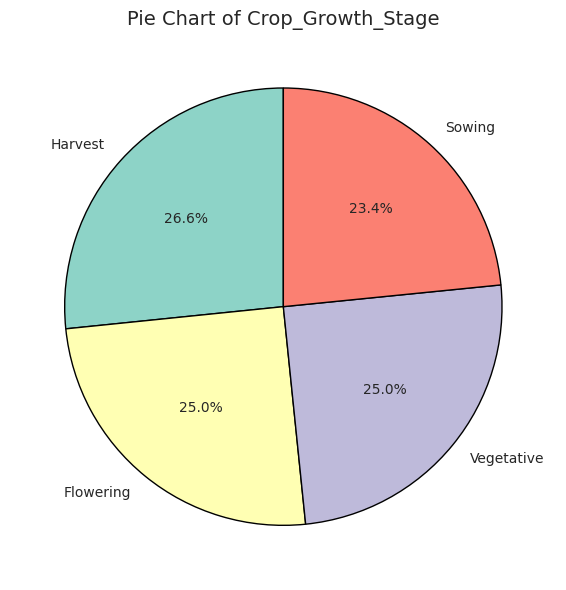

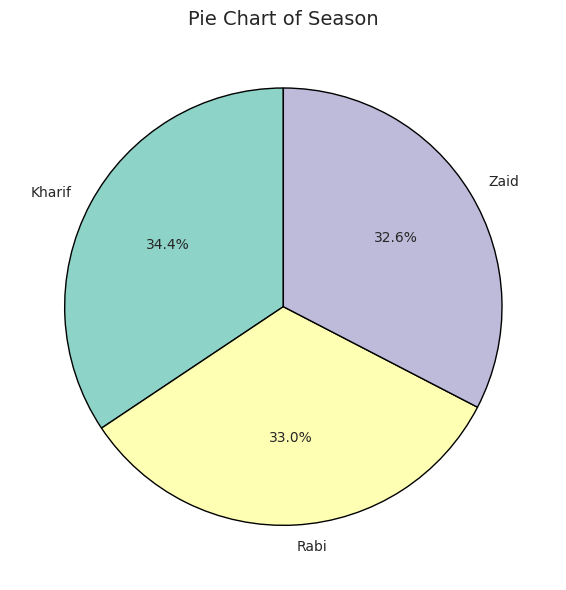

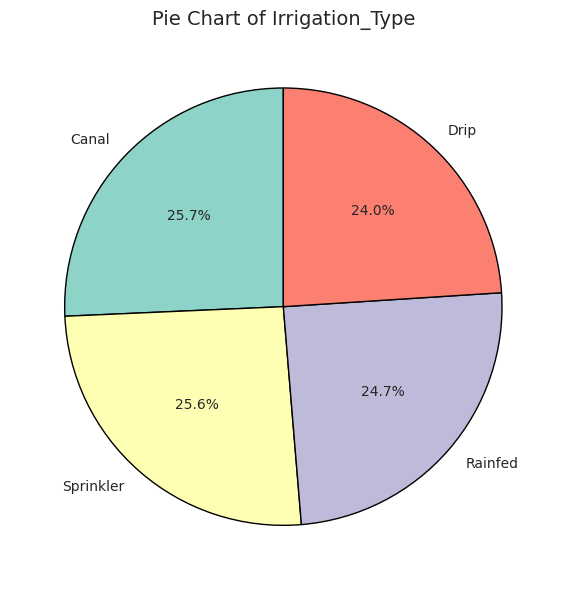

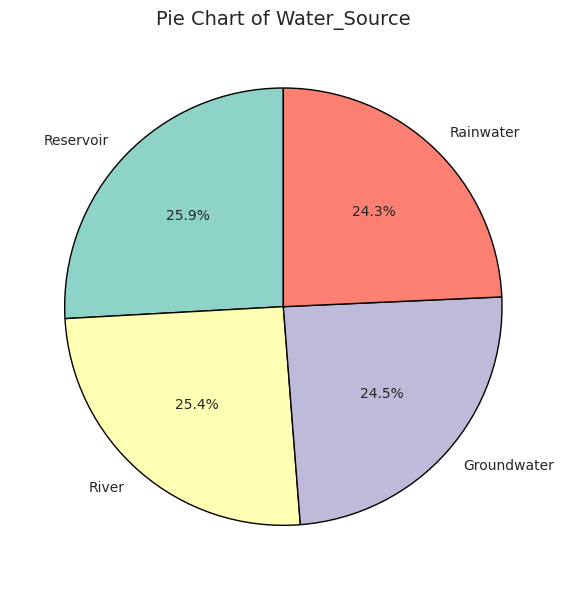

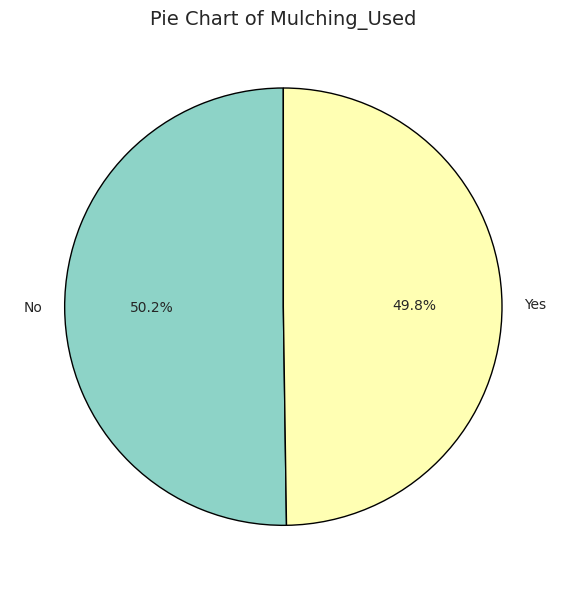

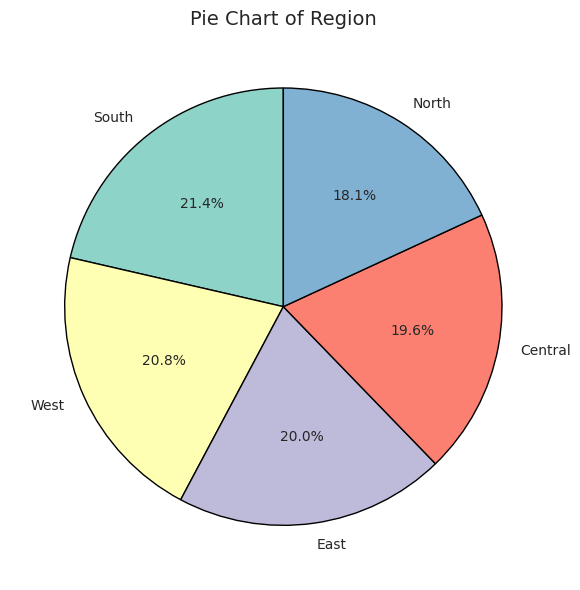

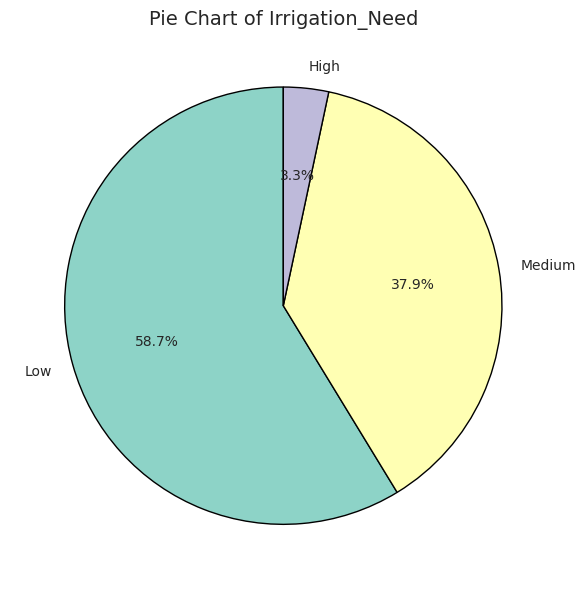

In [20]:
for col in categorical_columns:
    if df_train[col].nunique() <= 6:
        
        plt.figure(figsize=(6, 6))
        
        values = df_train[col].value_counts()
        
        # Color palette
        colors = sns.color_palette("Set3", len(values))
        
        plt.pie(
            values,
            labels=values.index,
            autopct='%1.1f%%',
            colors=colors,
            startangle=90,
            wedgeprops={'edgecolor': 'black'}
        )
        
        plt.title(f'Pie Chart of {col}', fontsize=14)
        plt.tight_layout()
        plt.show()

In [21]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_train['Irrigation_Need'] = le.fit_transform(df_train['Irrigation_Need'])

In [22]:
X = df_train.drop('Irrigation_Need', axis='columns')
y = df_train['Irrigation_Need']

from sklearn.preprocessing import MinMaxScaler

cols_to_scale = X.select_dtypes(['int64', 'float64']).columns

scaler = MinMaxScaler()

X[cols_to_scale] = scaler.fit_transform(X[cols_to_scale])
X.describe()

,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,Previous_Irrigation_mm
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,0.494852,0.514204,0.479122,0.483707,0.499939,0.522406,0.584892,0.501912,0.506430,0.491003,0.519281
std,0.271325,0.287368,0.281391,0.280094,0.287454,0.281585,0.245264,0.285617,0.291767,0.286947,0.285463
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.261765,0.269170,0.238462,0.244118,0.250583,0.291327,0.381781,0.251429,0.245128,0.243537,0.276069
50%,0.482353,0.522021,0.469231,0.482353,0.498667,0.523646,0.586874,0.511429,0.511795,0.481633,0.509544
75%,0.726471,0.759256,0.707692,0.729412,0.751333,0.773253,0.821787,0.750000,0.765641,0.737415,0.772443
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [23]:
!pip install statsmodels

In [24]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
def calculate_vif(data):
    # Ensure only numeric data
    data = data.select_dtypes(include=[np.number]).dropna()
    
    vif_df = pd.DataFrame()
    vif_df["Column"] = data.columns
    vif_df["VIF"] = [
        variance_inflation_factor(data.values, i)
        for i in range(data.shape[1])
    ]
    
    # Sort for better readability
    vif_df = vif_df.sort_values(by="VIF", ascending=False).reset_index(drop=True)
    
    return vif_df

In [25]:
df_train.head(5)

,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,16.79,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,1
1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,3.39,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,1
2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,3.85,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,1
3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,2.31,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,2
4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,13.94,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,1


In [26]:
def calculate_woe_iv(df, feature, target, bins=10):
    
    data = df[[feature, target]].copy()
    
    # Handle numerical features with binning
    if pd.api.types.is_numeric_dtype(data[feature]):
        data[feature] = pd.qcut(
            data[feature],
            q=bins,
            duplicates='drop'
        )
    
    # Grouping
    grouped = data.groupby(feature)[target].agg(['count', 'sum'])
    grouped.columns = ['total', 'good']
    
    # Assuming target = 1 is "good"
    grouped['bad'] = grouped['total'] - grouped['good']
    
    # Add smoothing to avoid division by zero
    grouped['good'] = grouped['good'].replace(0, 0.5)
    grouped['bad'] = grouped['bad'].replace(0, 0.5)
    
    total_good = grouped['good'].sum()
    total_bad = grouped['bad'].sum()
    
    grouped['good_pct'] = grouped['good'] / total_good
    grouped['bad_pct'] = grouped['bad'] / total_bad
    
    # WoE
    grouped['woe'] = np.log(grouped['good_pct'] / grouped['bad_pct'])
    
    # IV
    grouped['iv'] = (grouped['good_pct'] - grouped['bad_pct']) * grouped['woe']
    
    # Replace inf values
    grouped.replace([np.inf, -np.inf], 0, inplace=True)
    
    total_iv = grouped['iv'].sum()
    
    return grouped, total_iv


# ===============================
# 2. Compute IV for all features
# ===============================
def compute_iv_for_dataset(X, y):
    
    df = pd.concat([X, y], axis=1)
    target = y.name
    
    iv_dict = {}
    woe_tables = {}
    
    for col in X.columns:
        try:
            woe_table, iv = calculate_woe_iv(df, col, target)
            iv_dict[col] = iv
            woe_tables[col] = woe_table
        except Exception as e:
            print(f"Skipping {col}: {e}")
    
    iv_df = pd.DataFrame({
        'Feature': iv_dict.keys(),
        'IV': iv_dict.values()
    }).sort_values(by='IV', ascending=False).reset_index(drop=True)
    
    return iv_df, woe_tables


# ===============================
# 3. Run
# ===============================
iv_df, woe_tables = compute_iv_for_dataset(X, y)

print(iv_df)

                    Feature        IV
0         Crop_Growth_Stage  0.248492
1             Soil_Moisture  0.108064
2             Mulching_Used  0.040493
3            Wind_Speed_kmh  0.037075
4             Temperature_C  0.016826
5    Previous_Irrigation_mm  0.011778
6               Rainfall_mm  0.009403
7                  Humidity  0.004877
8                   Soil_pH  0.002232
9   Electrical_Conductivity  0.001650
10             Water_Source  0.001446
11       Field_Area_hectare  0.001445
12           Organic_Carbon  0.001191
13          Irrigation_Type  0.000959
14           Sunlight_Hours  0.000755
15                Crop_Type  0.000723
16                   Season  0.000432
17                   Region  0.000138
18                Soil_Type  0.000067


In [27]:
iv_values = {}

df_full = pd.concat([X, y], axis=1)

for col in X.columns:
    try:
        _, iv = calculate_woe_iv(df_full, col, y.name)
        iv_values[col] = iv
    except Exception as e:
        print(f"Skipping {col}: {e}")

In [28]:
def interpret_iv(iv):
    if iv < 0.02:
        return 'Not useful'
    elif iv < 0.1:
        return 'Weak'
    elif iv < 0.3:
        return 'Medium'
    elif iv < 0.5:
        return 'Strong'
    else:
        return 'Suspiciously Predictive'


# Convert dictionary to DataFrame
iv_summary = pd.DataFrame({
    'Feature': iv_values.keys(),
    'IV': iv_values.values()
})

# Add interpretation
iv_summary['Interpretation'] = iv_summary['IV'].apply(interpret_iv)

# Sort by importance
iv_summary = iv_summary.sort_values(by='IV', ascending=False).reset_index(drop=True)

print(iv_summary)

                    Feature        IV Interpretation
0         Crop_Growth_Stage  0.248492         Medium
1             Soil_Moisture  0.108064         Medium
2             Mulching_Used  0.040493           Weak
3            Wind_Speed_kmh  0.037075           Weak
4             Temperature_C  0.016826     Not useful
5    Previous_Irrigation_mm  0.011778     Not useful
6               Rainfall_mm  0.009403     Not useful
7                  Humidity  0.004877     Not useful
8                   Soil_pH  0.002232     Not useful
9   Electrical_Conductivity  0.001650     Not useful
10             Water_Source  0.001446     Not useful
11       Field_Area_hectare  0.001445     Not useful
12           Organic_Carbon  0.001191     Not useful
13          Irrigation_Type  0.000959     Not useful
14           Sunlight_Hours  0.000755     Not useful
15                Crop_Type  0.000723     Not useful
16                   Season  0.000432     Not useful
17                   Region  0.000138     Not 

## Thank you..pls upvote!!!!!!!